In [1]:
!pip install torchinfo

In [2]:

import os
import re
import cv2
import time
import glob
import random
import shutil
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from tabulate import tabulate
from tqdm import tqdm, notebook
from PIL import Image, ImageOps
import PIL
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    ColorJitter, RandomRotation, RandomResizedCrop
)
from torchvision.transforms.functional import gaussian_blur

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torchinfo import summary


This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


To ensure consistent and repeatable results across different runs, a fixed random seed is set here.
This controls the randomness in:
PyTorch CPU and GPU operations (torch.manual_seed, torch.cuda.manual_seed)
NumPy and Python’s built-in random module
Using the same seed guarantees that data shuffling, weight initialization, and other random processes produce the same outputs each time the notebook is executed.

In [4]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [ ]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)


df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [ ]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None 

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

 
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
     
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [8]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/2774541902737064.jpg,Good
1,/kaggle/working/dataset/Good/561329559537788.jpg,Good
2,/kaggle/working/dataset/Good/530762714594631.jpg,Good
3,/kaggle/working/dataset/Good/329163361890383.jpg,Good
4,/kaggle/working/dataset/Good/143900998161134.jpg,Good
5,/kaggle/working/dataset/Good/797949107906868.jpg,Good
6,/kaggle/working/dataset/Good/1374776550361355.jpg,Good
7,/kaggle/working/dataset/Good/3464229863800417.jpg,Good
8,/kaggle/working/dataset/Good/462646374960683.jpg,Good
9,/kaggle/working/dataset/Good/582605668218568.jpg,Good


This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

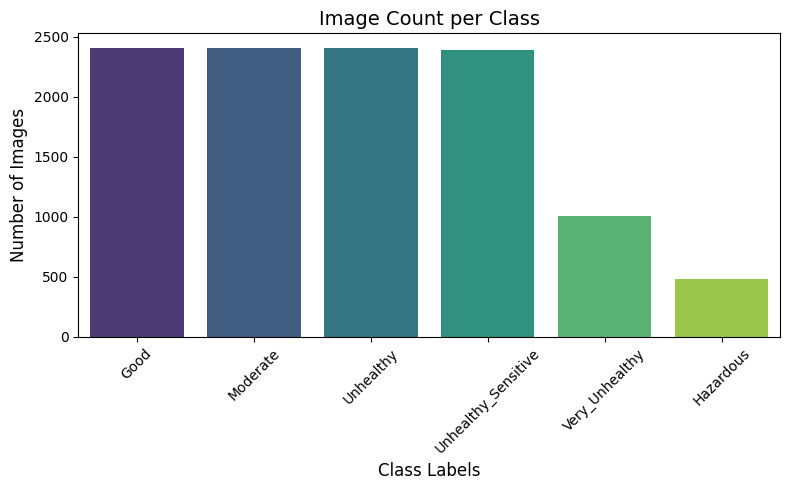

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

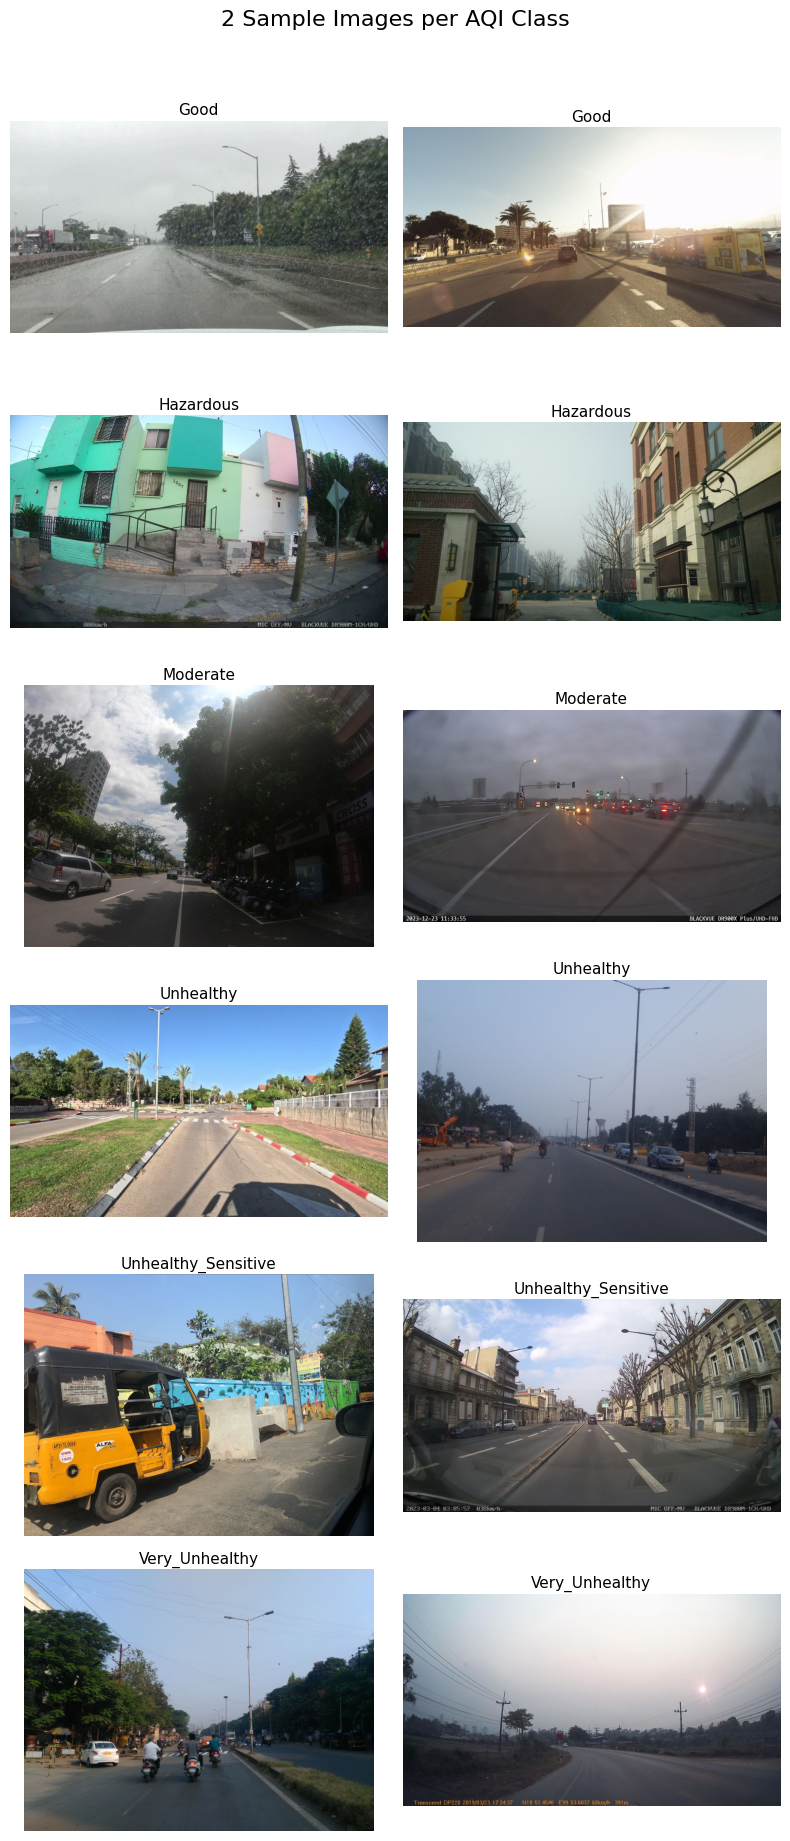

In [10]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This block divides the dataset into train, validation, and test sets for multiple ratios (from 90:10 down to 10:90).
Each split is stratified by class labels to keep class balance and uses a fixed random seed (42) for reproducibility.
From the training portion, 10% is further used as validation.
All splits are saved in dictionaries (SPLITS, FIXED_IDX) and a summary table shows image counts for every ratio

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path
import numpy as np
import os


OUT_DIR = Path("/kaggle/working/dataset")

rows = []
for class_dir in sorted([p for p in OUT_DIR.iterdir() if p.is_dir()]):
    label = class_dir.name
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(img_path), "label": label})

df = pd.DataFrame(rows)
print(f"✅ Found total {len(df)} images across {df['label'].nunique()} classes.")

RATIOS = [(90,10),(80,20),(70,30),(60,40),(50,50),(40,60),(30,70),(20,80),(10,90)]
RANDOM_STATE = 42


SPLITS = {}  
FIXED_IDX = {} 
all_idx = np.arange(len(df))
labels_all = df["label"].values


for tr, te in RATIOS:
    test_size = te / 100.0

    train_pool_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=labels_all,
        random_state=RANDOM_STATE
    )
    FIXED_IDX[(tr, te)] = {
        "train_pool_idx": train_pool_idx,
        "test_idx": test_idx
    }

    train_pool_df = df.iloc[train_pool_idx].reset_index(drop=True)
    tr_local_idx, va_local_idx = train_test_split(
        np.arange(len(train_pool_df)),
        test_size=0.10,
        stratify=train_pool_df["label"].values,
        random_state=RANDOM_STATE
    )

    train_idx = train_pool_idx[tr_local_idx]
    valid_idx = train_pool_idx[va_local_idx]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    SPLITS[(tr, te)] = {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df":  test_df
    }


print("\n=== Split Summary (counts) ===")
for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    print(f"{tr}:{te} -> train={len(s['train_df'])}, val={len(s['valid_df'])}, test={len(s['test_df'])}")
print("-------------------------------------------")
print("Total images in dataset: ", len(df))


✅ Found total 11103 images across 6 classes.

=== Split Summary (counts) ===
90:10 -> train=8992, val=1000, test=1111
80:20 -> train=7993, val=889, test=2221
70:30 -> train=6994, val=778, test=3331
60:40 -> train=5994, val=667, test=4442
50:50 -> train=4995, val=556, test=5552
40:60 -> train=3996, val=445, test=6662
30:70 -> train=2997, val=333, test=7773
20:80 -> train=1998, val=222, test=8883
10:90 -> train=999, val=111, test=9993
-------------------------------------------
Total images in dataset:  11103


This block prints class-wise image counts for train, validation, and test sets at each ratio using the tabulate library.
It helps verify that all splits remain balanced across classes and that no samples are missing.

In [12]:
from tabulate import tabulate

for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    train_df = s["train_df"]; valid_df = s["valid_df"]; test_df = s["test_df"]

    class_counts_train = train_df['label'].value_counts()
    class_counts_valid = valid_df['label'].value_counts()
    class_counts_test  = test_df['label'].value_counts()

    train_table_data = [[class_name, count] for class_name, count in class_counts_train.items()]
    valid_table_data = [[class_name, count] for class_name, count in class_counts_valid.items()]
    test_table_data  = [[class_name, count]  for class_name, count  in class_counts_test.items()]

    print(f"\n=== {tr}:{te} Split ===")
    print("\n Train Dataset")
    print(tabulate(train_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Validation Dataset")
    print(tabulate(valid_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Test Dataset")
    print(tabulate(test_table_data, headers=["Class", "Count"], tablefmt="github"))



=== 90:10 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |    1950 |
| Unhealthy           |    1949 |
| Moderate            |    1949 |
| Unhealthy_Sensitive |    1939 |
| Very_Unhealthy      |     815 |
| Hazardous           |     390 |

 Validation Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     217 |
| Moderate            |     217 |
| Unhealthy           |     217 |
| Unhealthy_Sensitive |     215 |
| Very_Unhealthy      |      91 |
| Hazardous           |      43 |

 Test Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     241 |
| Unhealthy           |     241 |
| Moderate            |     241 |
| Unhealthy_Sensitive |     239 |
| Very_Unhealthy      |     101 |
| Hazardous           |      48 |

=== 80:20 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Creates a base folder /kaggle/working/task2_efficientnet_b0 to store model checkpoints, logs, and outputs.
Ensures the directory exists before training begins.

In [14]:

save_root_base = "/kaggle/working/task2_efficientnet_b0"
os.makedirs(save_root_base, exist_ok=True)

Defines a reusable ImageDataset class for loading PM25Vision images in PyTorch.
It:
Reads image paths and labels from a DataFrame.
Converts labels into numeric indices via a mapping dictionary.
Loads each image in RGB format and applies given normalization transforms.
Optionally returns labels (is_lb=True) for training or just images for inferen

In [15]:
import PIL.Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=True):
        """
        Args:
            dataframe : pd.DataFrame containing 'path' and 'label' columns
            normalize : torchvision.transforms to apply to images
            is_lb     : bool, True if labels should be returned
        """
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['path']
        image = PIL.Image.open(img_path).convert("RGB")  

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

Implemented data transformation and DataLoader pipeline.
Added ImageNet-based normalization using Resize → ToTensor → Normalize tailored for efficientnet_b0  input preprocessing.
Created separate DataLoaders for training, validation, and testing datasets.
Used batch sizes 32 for training and 8 for validation/testing.
Ensures consistent preprocessing and efficient batching for efficientnet_b0  workflow.

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

train_batch = 32
val_batch = 8

def data_transform(train_df, valid_df, test_df):

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    normalize = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    train_dataset = ImageDataset(
        train_df,
        normalize,
        is_lb=True
    )

    valid_dataset = ImageDataset(
        valid_df,
        normalize,
        is_lb=True
    )

    test_dataset = ImageDataset(
        test_df,
        normalize,
        is_lb=True
    )

  
    dataloader_train_dataset = DataLoader(
        train_dataset, batch_size=train_batch, shuffle=True, num_workers=2
    )
    dataloader_valid_dataset = DataLoader(
        valid_dataset, batch_size=val_batch, shuffle=False, num_workers=2
    )
    dataloader_test_dataset = DataLoader(
        test_dataset, batch_size=val_batch, shuffle=False, num_workers=2
    )

    return dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset


Initialized EfficientNet-B0 model for multi-class classification.
Replaced the final classifier layer with a new fully connected layer matching the total number of classes.
Defined Adam optimizer with a learning rate of 0.0001 and CrossEntropyLoss as the training criterion.
Displayed model summary and computed computational complexity metrics (MACs, FLOPs, and parameters) using THOP profiling.
Ensures optimized architecture setup and performance transparency for the EfficientNet-B0 workflow.

In [ ]:
total_class = len(df['label'].unique())   
learning_rate = 0.0001

model = models.efficientnet_b0(pretrained=True)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, total_class)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(train_batch, 3, 224, 224))

try:
    from thop import profile
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "thop"])
    from thop import profile

model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    macs, params = profile(model, inputs=(dummy,), verbose=False)

gmacs  = macs / 1e9
gflops = (2 * macs) / 1e9   
mparams = params / 1e6

print(f"[Complexity @224x224]  MACs: {gmacs:.2f} GMACs  (~{gflops:.2f} GFLOPs)  |  Params: {mparams:.2f} M")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


[Complexity @224x224]  MACs: 0.41 GMACs  (~0.83 GFLOPs)  |  Params: 4.02 M


Trains EfficientNet-B0 for each (train : test) ratio in RATIOS using the Adam optimizer and CrossEntropyLoss for 50 epochs. The train_model(...) function displays live tqdm progress bars, tracks training and validation loss and accuracy, and saves the best model checkpoint (model.pt) whenever validation accuracy improves. After each ratio run, it logs epoch-wise metrics (Train Loss, Train Acc, Val Loss, Val Acc) into training_data.xlsx inside that ratio’s checkpoint directory, prints total training time and average seconds per epoch, and appends summary information to RESULTS_ROWS. Finally, it reports the overall wall-clock time across all ratios once every experiment finishes.

In [ ]:
start_time_global = time.time()

def train_model(model, criterion, optimizer, dataloader_train_dataset, dataloader_valid_dataset, num_epochs=50, save_path_checkpoints="checkpoints"):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    os.makedirs(save_path_checkpoints, exist_ok=True)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()  
        # Training phase
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        progress_bar = tqdm(enumerate(dataloader_train_dataset), total=len(dataloader_train_dataset))
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(loss=running_loss / total_train, acc=correct_train / total_train)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        print('Training Loss: {:.3f} Acc: {:.3f}'.format(epoch_train_loss, epoch_train_acc))
# Validation phase
        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in dataloader_valid_dataset:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                running_loss += loss.item() * inputs.size(0)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        print('Validation Loss: {:.3f} Acc: {:.3f}'.format(epoch_val_loss, epoch_val_acc))

    
        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1} Time: {epoch_time:.2f} seconds")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            filepath = f"{save_path_checkpoints}/model.pt"
            checkpoint = {
                "epoch": epoch + 1,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }
            torch.save(checkpoint, filepath)
            print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.3f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history
import json
RESULTS_ROWS = []  
for (tr, te) in RATIOS:
    print(f"\n================= Running Efficientnet_b0 for ratio {tr}:{te} =================")
    split = SPLITS[(tr, te)]
    tr_df = split["train_df"]; va_df = split["valid_df"]; te_df = split["test_df"]

    dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset = data_transform(tr_df, va_df, te_df)

    model_ratio = models.efficientnet_b0(pretrained=True)
    num_ftrs = model_ratio.classifier[1].in_features
    model_ratio.classifier[1] = nn.Linear(num_ftrs, len(df['label'].unique()))
    model_ratio = model_ratio.to(device)

    optimizer_ratio = optim.Adam(model_ratio.parameters(), lr=learning_rate)
    criterion_ratio = nn.CrossEntropyLoss()

  
    save_path_checkpoints = os.path.join(save_root_base, f"{tr}_{te}")
    os.makedirs(save_path_checkpoints, exist_ok=True)

    start_time = time.time()

    train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
        model_ratio, criterion_ratio, optimizer_ratio,
        dataloader_train_dataset, dataloader_valid_dataset,
        num_epochs=50, save_path_checkpoints=save_path_checkpoints
    )
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time [{tr}:{te}]: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")
 
    print(f"Average Per-Epoch Time [{tr}:{te}]: {training_time/50:.2f} seconds/epoch")


    data_hist = {
        'Epoch': list(range(1, len(train_loss_history) + 1)),
        'Train Loss': train_loss_history,
        'Train Accuracy': train_acc_history,
        'Validation Loss': val_loss_history,
        'Validation Accuracy': val_acc_history
    }
    history = pd.DataFrame(data_hist)
    hist_path = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    history.to_excel(hist_path, index=False)

    
    RESULTS_ROWS.append({
        "ratio": f"{tr}:{te}",
        "checkpoint_dir": save_path_checkpoints,
        "history_path": hist_path
    })


end_time_global = time.time()
print(f"\n=== All ratios done in {end_time_global - start_time_global:.2f} seconds ===")


================= Running Efficientnet_b0 for ratio 90:10 =================


Epoch 1/50: 100%|██████████| 281/281 [01:06<00:00,  4.20it/s, acc=0.426, loss=1.38]

Training Loss: 1.383 Acc: 0.426


Validation Loss: 1.110 Acc: 0.525
Epoch 1 Time: 74.22 seconds
Best model saved at epoch 1 with validation accuracy: 0.525


Epoch 2/50: 100%|██████████| 281/281 [01:06<00:00,  4.21it/s, acc=0.624, loss=0.947]

...

Training Loss: 0.038 Acc: 0.990


Validation Loss: 2.214 Acc: 0.459
Epoch 49 Time: 11.08 seconds


Epoch 50/50: 100%|██████████| 32/32 [00:07<00:00,  4.22it/s, acc=0.994, loss=0.0258]

Training Loss: 0.026 Acc: 0.994


Validation Loss: 2.165 Acc: 0.505
Epoch 50 Time: 8.59 seconds
Training Time [10:90]: 444.35 seconds ---> 7.41 minutes
Average Per-Epoch Time [10:90]: 8.89 seconds/epoch

=== All ratios done in 18758.81 seconds ===


This block plots loss and accuracy curves from each ratio’s training history (training_data.xlsx).
It shows side-by-side subplots for train vs validation performance across epochs, saves each plot as curves.png inside the corresponding checkpoint folder, and displays them for review.

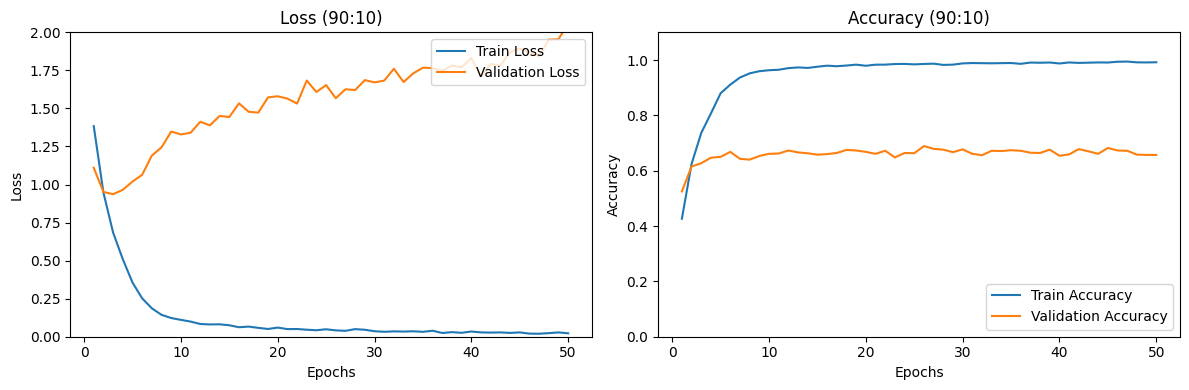

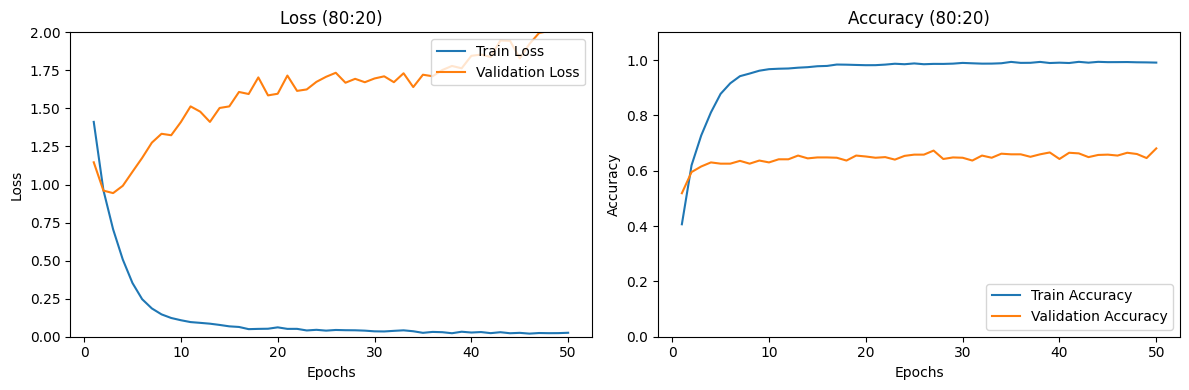

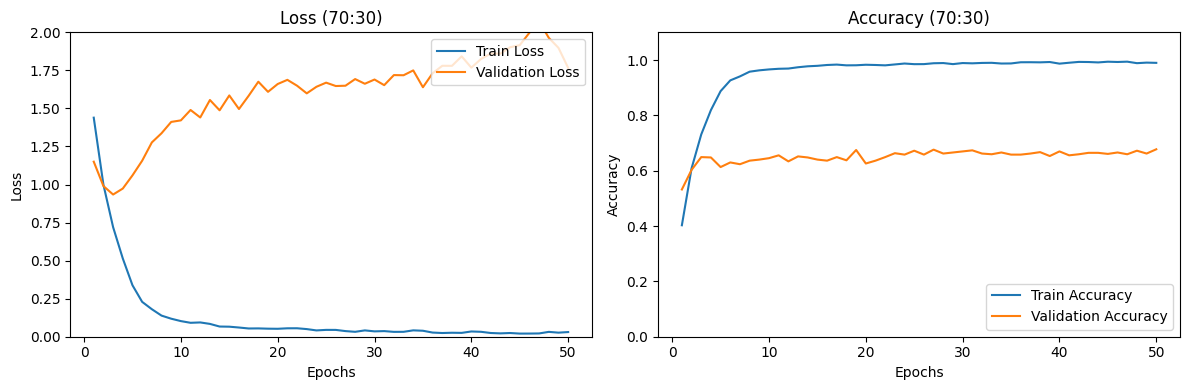

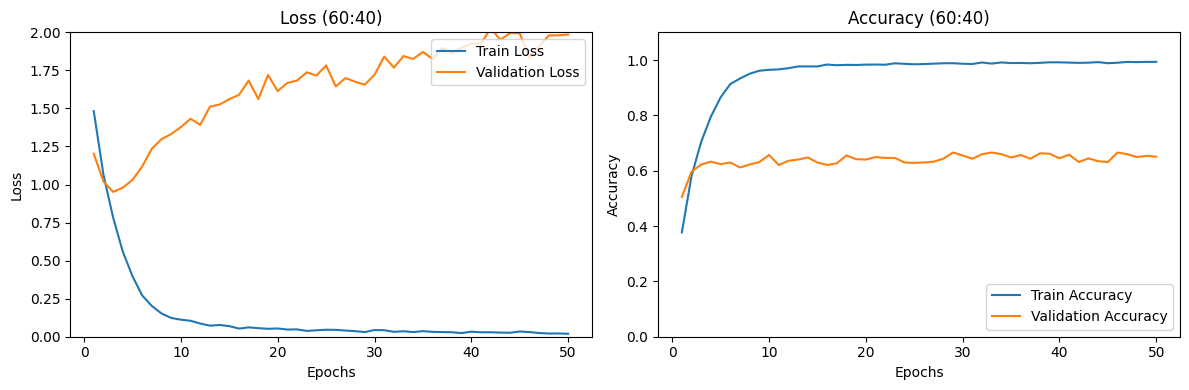

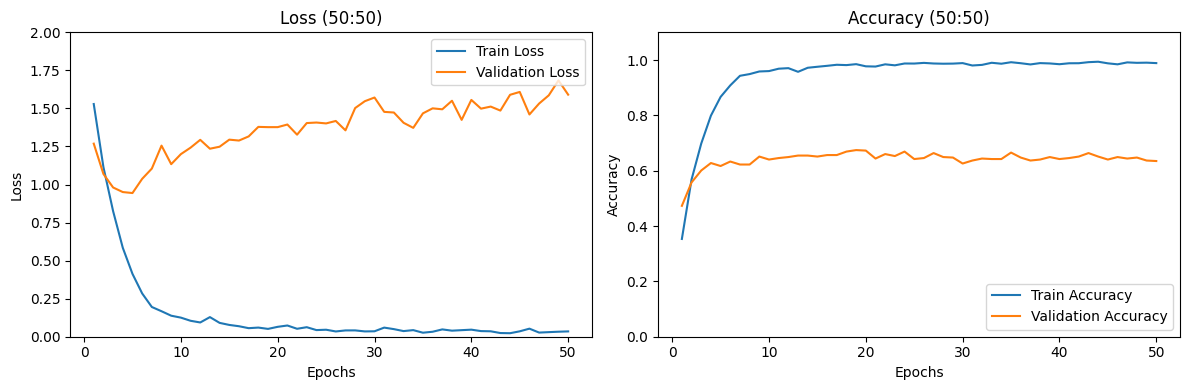

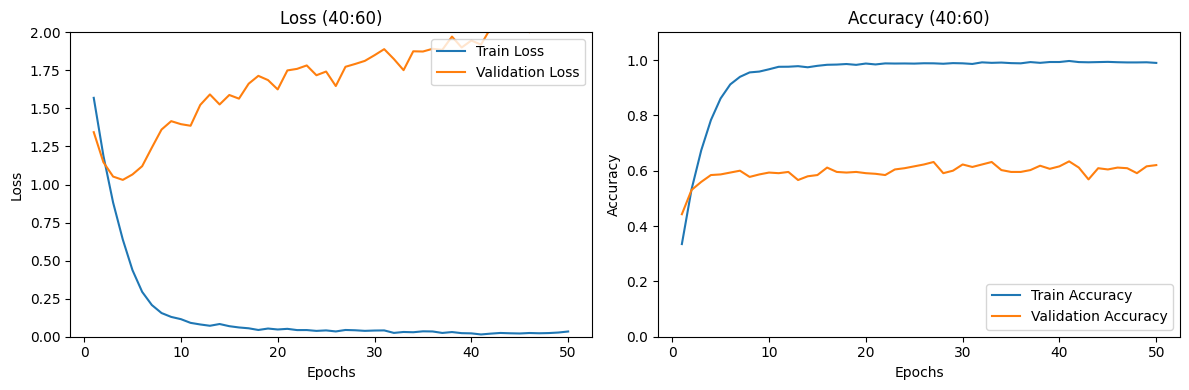

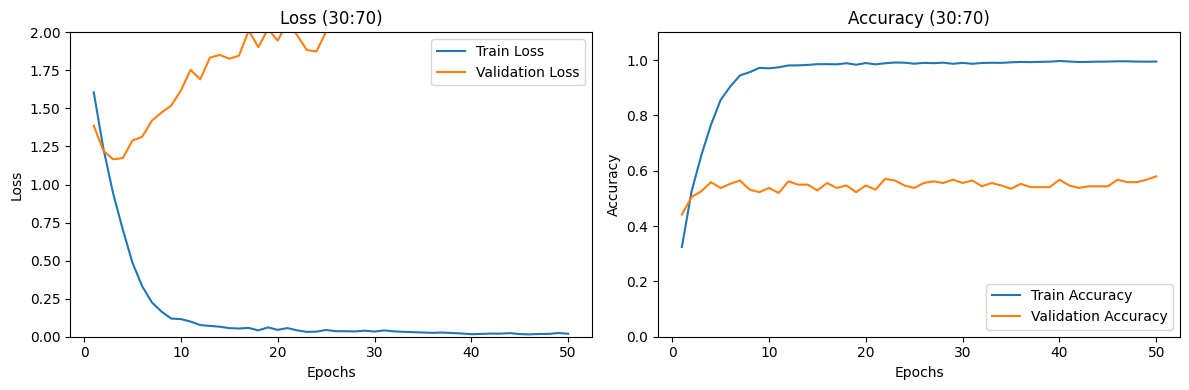

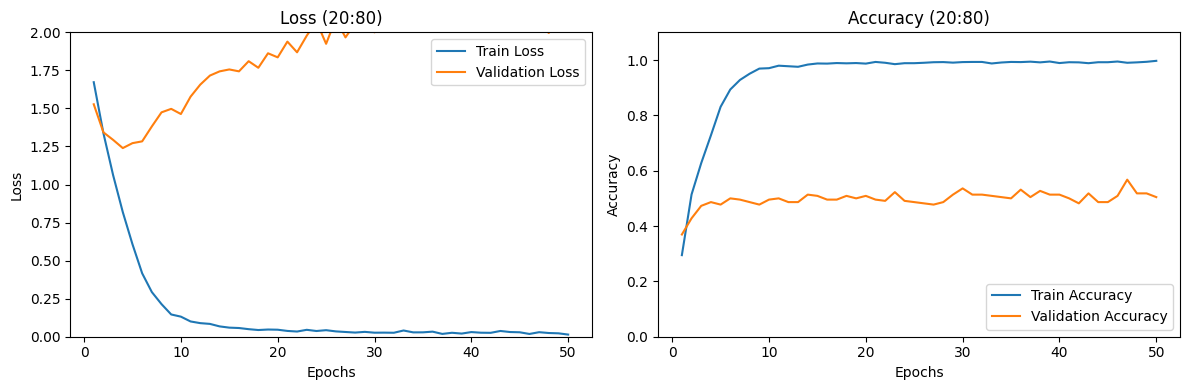

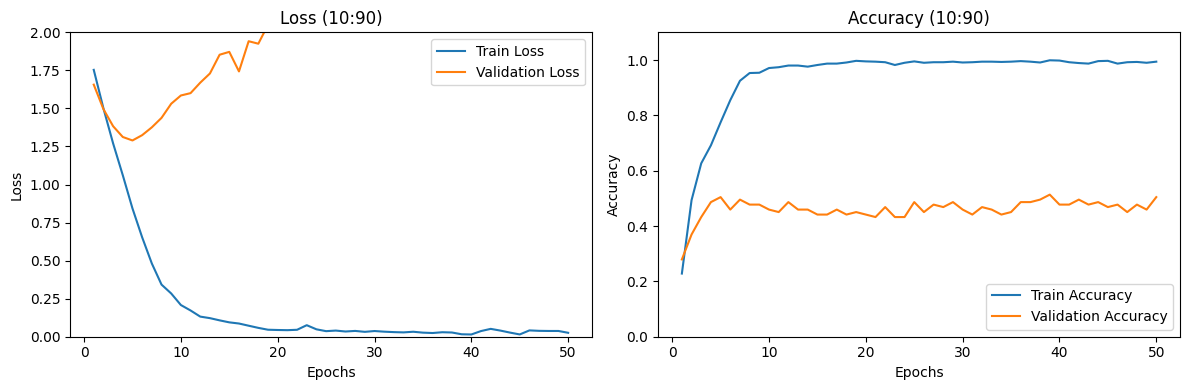

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

for (tr, te) in RATIOS:
    save_path_checkpoints = os.path.join("/kaggle/working/task2_efficientnet_b0", f"{tr}_{te}")
    hist_xlsx = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    if not os.path.exists(hist_xlsx):
        print(f"[{tr}:{te}] history file missing at {hist_xlsx}")
        continue

    history = pd.read_excel(hist_xlsx)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss')
    plt.plot(history['Epoch'], history['Validation Loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss ({tr}:{te})')
    plt.legend(loc='upper right')
    plt.ylim(0, 2)

    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy')
    plt.plot(history['Epoch'], history['Validation Accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy ({tr}:{te})')
    plt.legend(loc='lower right')
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plot_path = os.path.join(save_path_checkpoints, "curves.png")
    plt.savefig(plot_path)
    plt.show()

ChatGPT said:

Defines evaluate_model() to test a trained model on any dataset. It computes the average loss and overall accuracy, and optionally returns predicted labels, true labels, and softmax probabilities when return_preds=True. The function runs the model in evaluation mode (model.eval()) within a torch.no_grad() block to disable gradient calculations during inference, ensuring faster and memory-efficient evaluation.

In [20]:
import torch
import numpy as np

def evaluate_model(model, criterion, dataloader, return_preds=False):
    """
    Evaluate model on given dataloader.

    Args:
        model: PyTorch model
        criterion: loss function
        dataloader: DataLoader for evaluation
        return_preds: bool, if True returns all predictions and labels (and probs)

    Returns:
        loss: average loss
        accuracy: overall accuracy
        (optional) all_preds, all_labels, all_probs (softmax)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if return_preds:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    loss = running_loss / total 
    accuracy = correct / total

    if return_preds:
        return loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    else:
        return loss, accuracy

Evaluates the best EfficientNet-B0 checkpoints for each (train : test) ratio in RATIOS.
For every ratio, it reloads the saved model.pt (including model and optimizer states), reconstructs the same EfficientNet-B0 architecture, and restores the learned weights.
Using the corresponding validation DataLoader from SPLITS, it calls evaluate_model(...) to compute the validation loss and accuracy of the best epoch.
Finally, it prints the epoch number the checkpoint came from along with the evaluated validation performance metrics for each ratio.

In [ ]:
import os
import torch

for (tr, te) in RATIOS:
    print(f"\n[Validation Eval] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_efficientnet_b0", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    model = models.efficientnet_b0(pretrained=True).to(device)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, len(df['label'].unique()))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_epoch = checkpoint["epoch"]
    model.load_state_dict(checkpoint["model_weight"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])  


    split = SPLITS[(tr, te)]
    _, dataloader_valid_dataset, _ = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    best_val_loss, best_val_accuracy = evaluate_model(model, criterion, dataloader_valid_dataset)
    print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")



[Validation Eval] Ratio 90:10


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Best model (from epoch 26) - Validation Loss: 1.567, Validation Accuracy: 0.689

[Validation Eval] Ratio 80:20
Best model (from epoch 50) - Validation Loss: 2.022, Validation Accuracy: 0.681

[Validation Eval] Ratio 70:30
Best model (from epoch 50) - Validation Loss: 1.767, Validation Accuracy: 0.677

[Validation Eval] Ratio 60:40
Best model (from epoch 29) - Validation Loss: 1.656, Validation Accuracy: 0.666

[Validation Eval] Ratio 50:50
Best model (from epoch 19) - Validation Loss: 1.377, Validation Accuracy: 0.674

[Validation Eval] Ratio 40:60
Best model (from epoch 41) - Validation Loss: 1.919, Validation Accuracy: 0.634

[Validation Eval] Ratio 30:70
Best model (from epoch 50) - Validation Loss: 2.230, Validation Accuracy: 0.580

[Validation Eval] Ratio 20:80
Best model (from epoch 47) - Validation Loss: 2.055, Validation Accuracy: 0.568

[Validation Eval] Ratio 10:90
Best model (from epoch 39) - Validation Loss: 2.178, Validation Accuracy: 0.514


Evaluates EfficientNet-B0 on the test set for each (train : test) ratio using the best saved checkpoint. It reloads the model, runs evaluate_model(...) to compute loss, accuracy, and prediction stats, then reports total and per-image inference time. Generates a confusion matrix, classification report, and macro ROC–AUC, saving normalized CM and ROC curve plots. Finally, lists the top-5 most confused class pairs to highlight key misclassifications.


[TEST] Ratio 90:10
Test Loss: 1.516, Test Accuracy: 0.676
Total Test Time: 8.15 seconds for 1111 images
Average Inference Time per Image: 0.007339 s (~7.34 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.564315
1            Hazardous  0.916667
2             Moderate  0.443983
3            Unhealthy  0.842324
4  Unhealthy_Sensitive  0.732218
5       Very_Unhealthy  0.851485

Classification Report:

                     precision    recall  f1-score   support

               Good     0.6210    0.5643    0.5913       241
          Hazardous     0.8627    0.9167    0.8889        48
           Moderate     0.4977    0.4440    0.4693       241
          Unhealthy     0.8153    0.8423    0.8286       241
Unhealthy_Sensitive     0.6295    0.7322    0.6770       239
     Very_Unhealthy     0.8687    0.8515    0.8600       101

           accuracy                         0.6760      1111
          macro avg     0.7158    0.7252    0.7192      1111
     

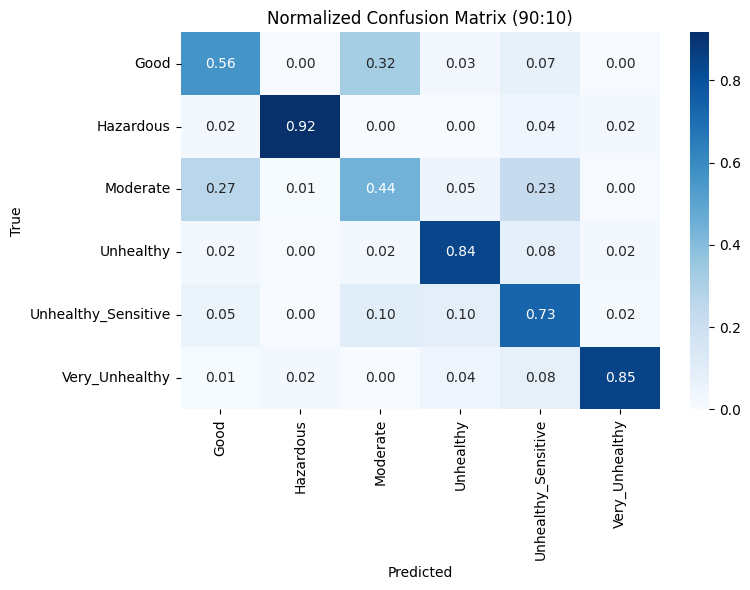

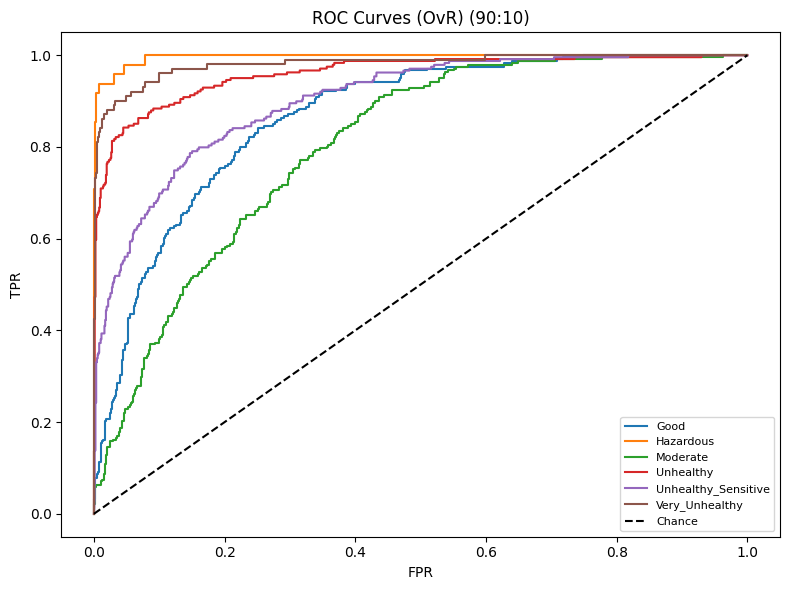


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.32
            Moderate → Good               : 0.27
            Moderate → Unhealthy_Sensitive : 0.23
  Unhealthy_Sensitive → Moderate           : 0.10
  Unhealthy_Sensitive → Unhealthy          : 0.10

[TEST] Ratio 80:20


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.852, Test Accuracy: 0.683
Total Test Time: 16.05 seconds for 2221 images
Average Inference Time per Image: 0.007224 s (~7.22 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.709544
1            Hazardous  0.885417
2             Moderate  0.417012
3            Unhealthy  0.850312
4  Unhealthy_Sensitive  0.638831
5       Very_Unhealthy  0.860697

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5856    0.7095    0.6417       482
          Hazardous     0.7870    0.8854    0.8333        96
           Moderate     0.5289    0.4170    0.4664       482
          Unhealthy     0.8196    0.8503    0.8347       481
Unhealthy_Sensitive     0.6955    0.6388    0.6659       479
     Very_Unhealthy     0.8238    0.8607    0.8418       201

           accuracy                         0.6826      2221
          macro avg     0.7068    0.7270    0.7140      2221
       weighted avg     

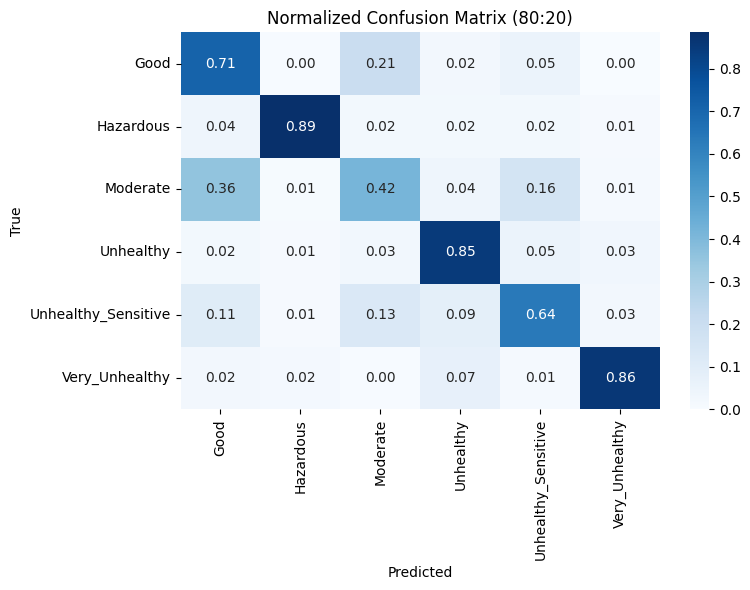

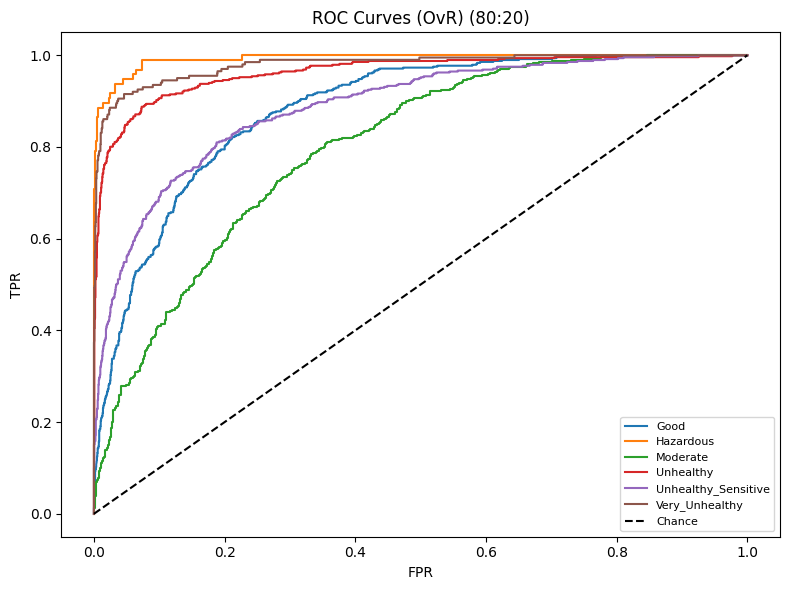


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.36
                Good → Moderate           : 0.21
            Moderate → Unhealthy_Sensitive : 0.16
  Unhealthy_Sensitive → Moderate           : 0.13
  Unhealthy_Sensitive → Good               : 0.11

[TEST] Ratio 70:30


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.810, Test Accuracy: 0.662
Total Test Time: 24.06 seconds for 3331 images
Average Inference Time per Image: 0.007223 s (~7.22 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.609959
1            Hazardous  0.833333
2             Moderate  0.500000
3            Unhealthy  0.846260
4  Unhealthy_Sensitive  0.623955
5       Very_Unhealthy  0.738411

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5880    0.6100    0.5988       723
          Hazardous     0.7643    0.8333    0.7973       144
           Moderate     0.5042    0.5000    0.5021       722
          Unhealthy     0.7783    0.8463    0.8109       722
Unhealthy_Sensitive     0.6798    0.6240    0.6507       718
     Very_Unhealthy     0.8447    0.7384    0.7880       302

           accuracy                         0.6617      3331
          macro avg     0.6932    0.6920    0.6913      3331
       weighted avg     

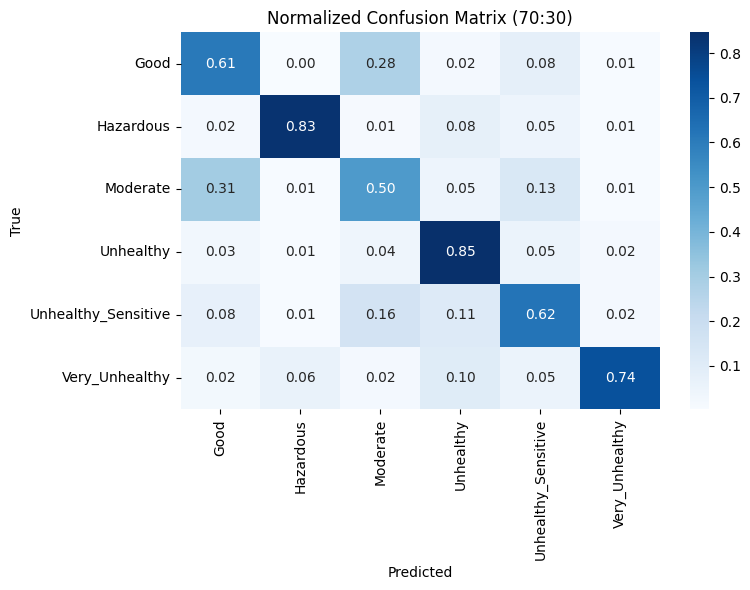

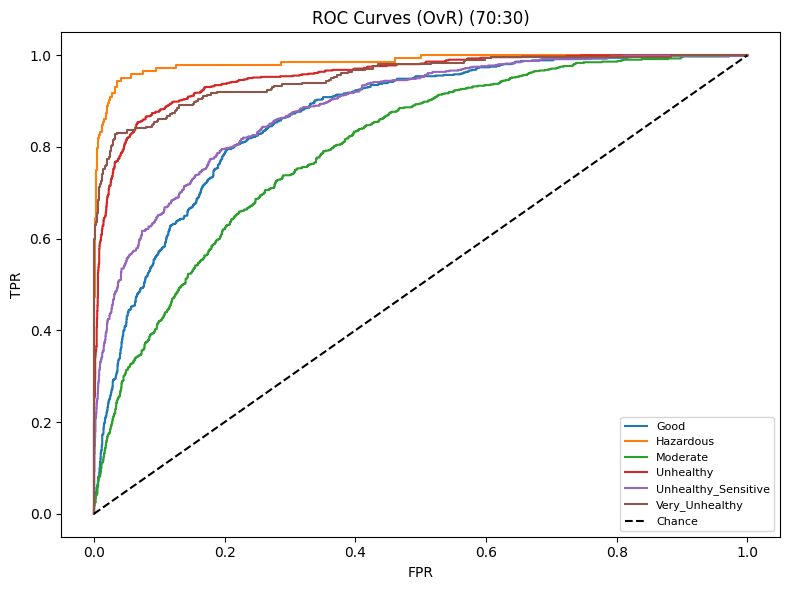


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.31
                Good → Moderate           : 0.28
  Unhealthy_Sensitive → Moderate           : 0.16
            Moderate → Unhealthy_Sensitive : 0.13
  Unhealthy_Sensitive → Unhealthy          : 0.11

[TEST] Ratio 60:40


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.779, Test Accuracy: 0.630
Total Test Time: 32.41 seconds for 4442 images
Average Inference Time per Image: 0.007296 s (~7.30 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.630322
1            Hazardous  0.782383
2             Moderate  0.409138
3            Unhealthy  0.807892
4  Unhealthy_Sensitive  0.593521
5       Very_Unhealthy  0.749380

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5710    0.6303    0.5992       963
          Hazardous     0.7550    0.7824    0.7684       193
           Moderate     0.4758    0.4091    0.4400       963
          Unhealthy     0.7374    0.8079    0.7711       963
Unhealthy_Sensitive     0.6174    0.5935    0.6052       957
     Very_Unhealthy     0.8032    0.7494    0.7754       403

           accuracy                         0.6303      4442
          macro avg     0.6600    0.6621    0.6599      4442
       weighted avg     

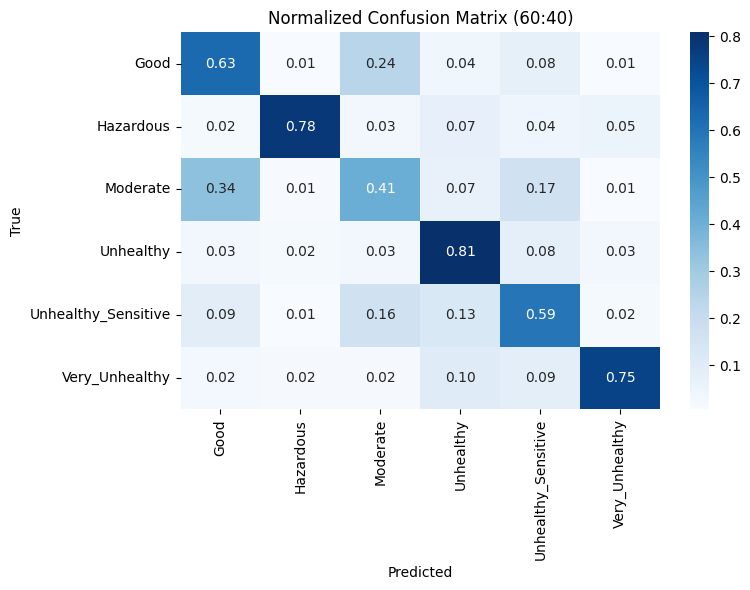

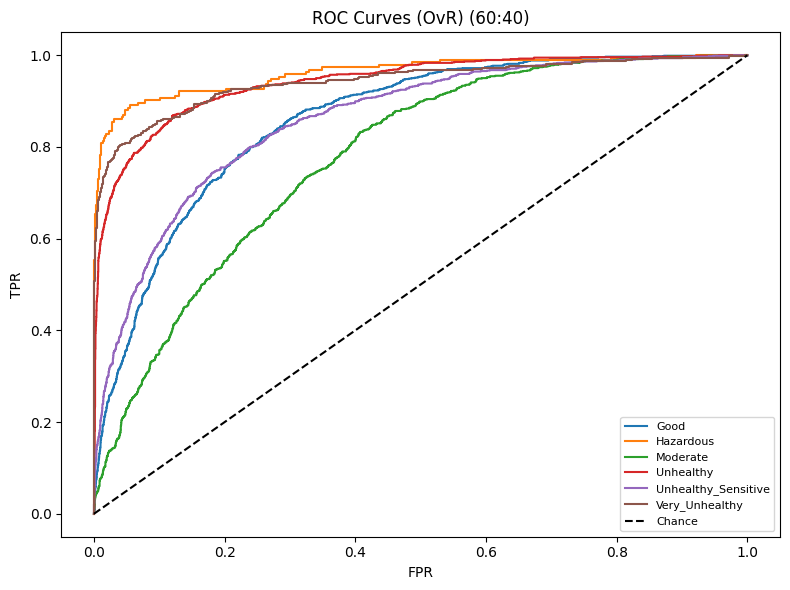


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.34
                Good → Moderate           : 0.24
            Moderate → Unhealthy_Sensitive : 0.17
  Unhealthy_Sensitive → Moderate           : 0.16
  Unhealthy_Sensitive → Unhealthy          : 0.13

[TEST] Ratio 50:50


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.649, Test Accuracy: 0.628
Total Test Time: 40.06 seconds for 5552 images
Average Inference Time per Image: 0.007216 s (~7.22 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.625415
1            Hazardous  0.766667
2             Moderate  0.474252
3            Unhealthy  0.792359
4  Unhealthy_Sensitive  0.553885
5       Very_Unhealthy  0.723658

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5628    0.6254    0.5924      1204
          Hazardous     0.7302    0.7667    0.7480       240
           Moderate     0.4782    0.4743    0.4762      1204
          Unhealthy     0.7471    0.7924    0.7690      1204
Unhealthy_Sensitive     0.6513    0.5539    0.5986      1197
     Very_Unhealthy     0.7696    0.7237    0.7459       503

           accuracy                         0.6284      5552
          macro avg     0.6565    0.6560    0.6550      5552
       weighted avg     

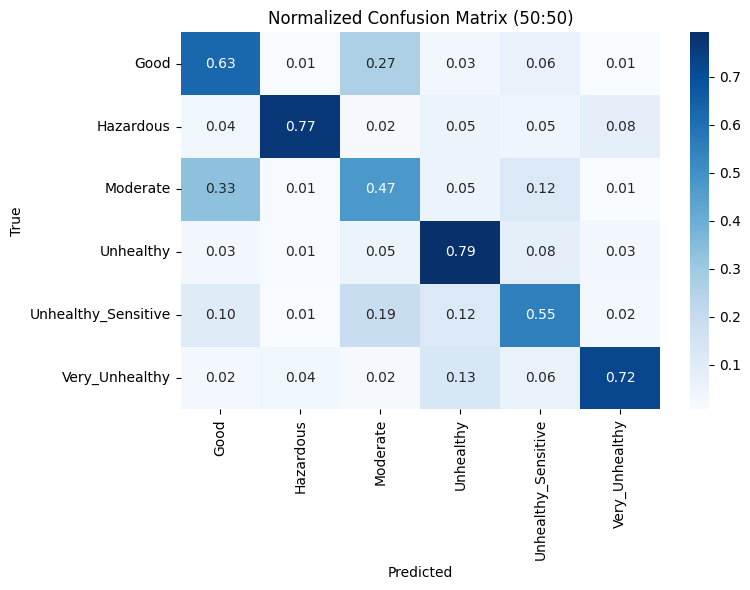

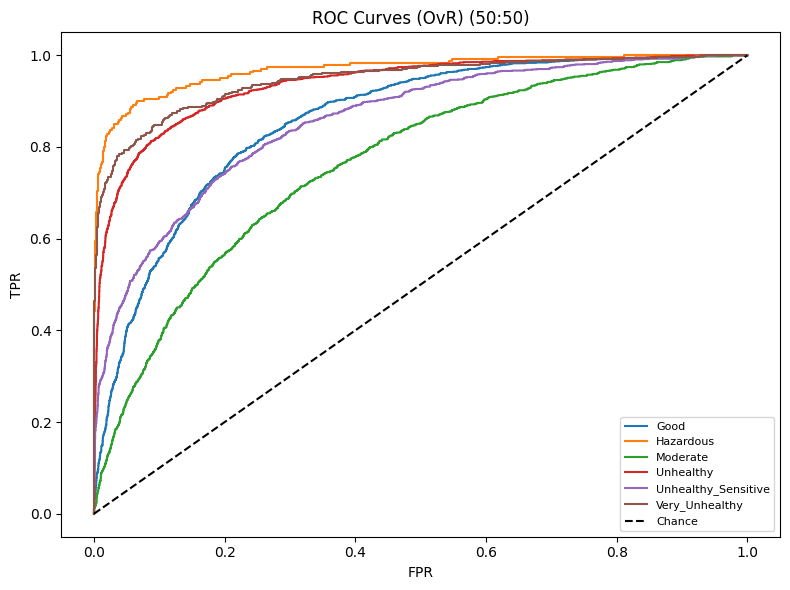


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.33
                Good → Moderate           : 0.27
  Unhealthy_Sensitive → Moderate           : 0.19
      Very_Unhealthy → Unhealthy          : 0.13
  Unhealthy_Sensitive → Unhealthy          : 0.12

[TEST] Ratio 40:60


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.931, Test Accuracy: 0.621
Total Test Time: 50.41 seconds for 6662 images
Average Inference Time per Image: 0.007568 s (~7.57 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.591003
1            Hazardous  0.788927
2             Moderate  0.464681
3            Unhealthy  0.776316
4  Unhealthy_Sensitive  0.576602
5       Very_Unhealthy  0.718543

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5825    0.5910    0.5867      1445
          Hazardous     0.7729    0.7889    0.7808       289
           Moderate     0.4519    0.4647    0.4582      1444
          Unhealthy     0.7308    0.7763    0.7529      1444
Unhealthy_Sensitive     0.6170    0.5766    0.5961      1436
     Very_Unhealthy     0.8037    0.7185    0.7587       604

           accuracy                         0.6208      6662
          macro avg     0.6598    0.6527    0.6556      6662
       weighted avg     

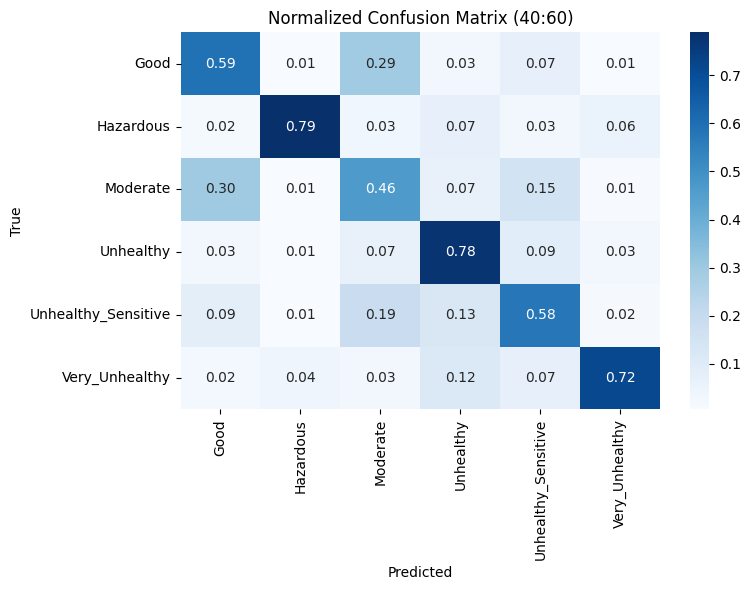

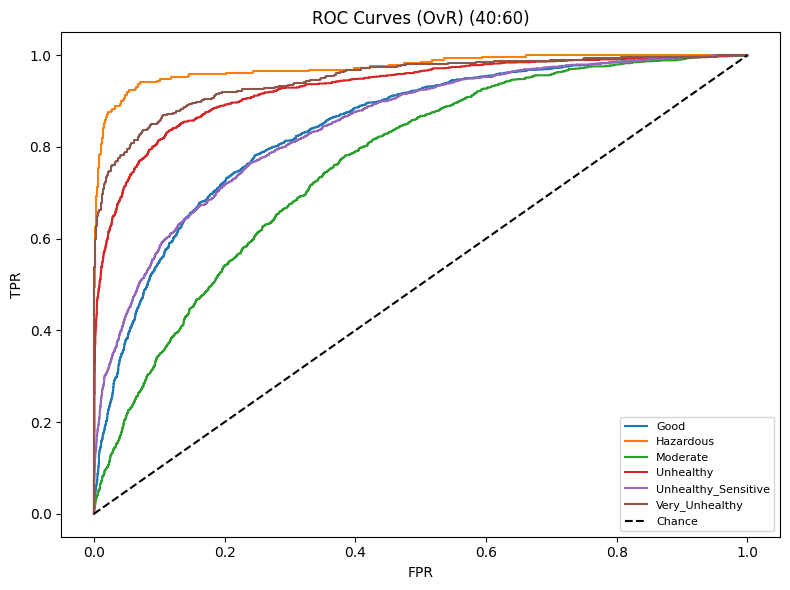


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.30
                Good → Moderate           : 0.29
  Unhealthy_Sensitive → Moderate           : 0.19
            Moderate → Unhealthy_Sensitive : 0.15
  Unhealthy_Sensitive → Unhealthy          : 0.13

[TEST] Ratio 30:70


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 2.130, Test Accuracy: 0.582
Total Test Time: 56.12 seconds for 7773 images
Average Inference Time per Image: 0.007220 s (~7.22 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.608541
1            Hazardous  0.780415
2             Moderate  0.344214
3            Unhealthy  0.717507
4  Unhealthy_Sensitive  0.579701
5       Very_Unhealthy  0.675177

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5490    0.6085    0.5772      1686
          Hazardous     0.7367    0.7804    0.7579       337
           Moderate     0.4531    0.3442    0.3912      1685
          Unhealthy     0.6889    0.7175    0.7029      1685
Unhealthy_Sensitive     0.5218    0.5797    0.5492      1675
     Very_Unhealthy     0.7312    0.6752    0.7021       705

           accuracy                         0.5821      7773
          macro avg     0.6134    0.6176    0.6134      7773
       weighted avg     

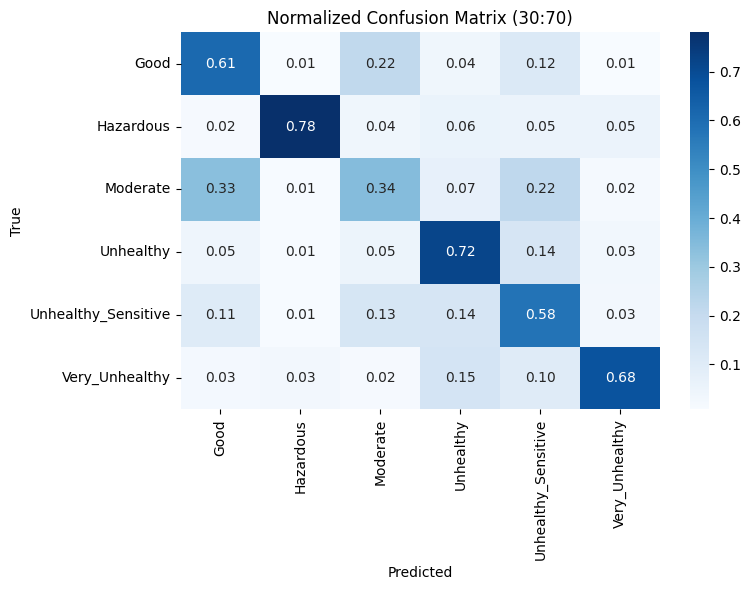

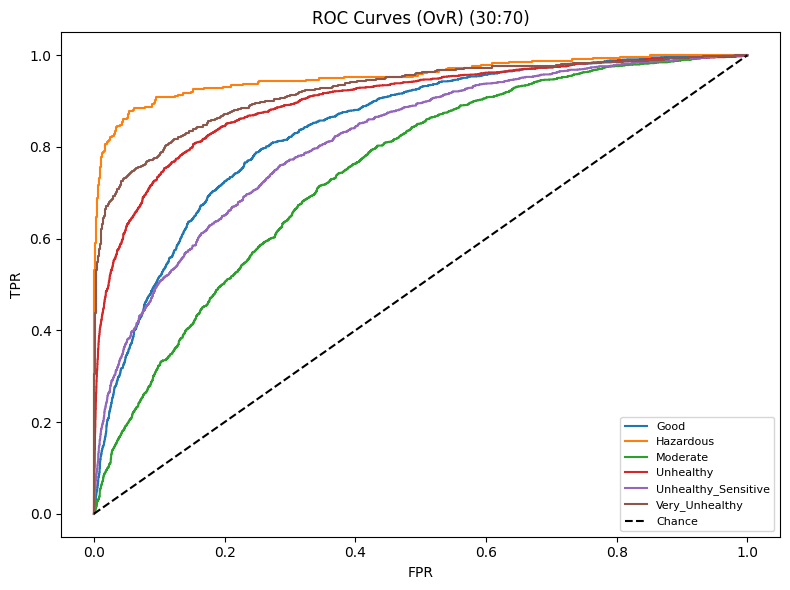


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.33
            Moderate → Unhealthy_Sensitive : 0.22
                Good → Moderate           : 0.22
      Very_Unhealthy → Unhealthy          : 0.15
           Unhealthy → Unhealthy_Sensitive : 0.14

[TEST] Ratio 20:80


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 2.191, Test Accuracy: 0.534
Total Test Time: 63.51 seconds for 8883 images
Average Inference Time per Image: 0.007150 s (~7.15 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.557113
1            Hazardous  0.641558
2             Moderate  0.341121
3            Unhealthy  0.754933
4  Unhealthy_Sensitive  0.459248
5       Very_Unhealthy  0.540943

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5199    0.5571    0.5378      1926
          Hazardous     0.7462    0.6416    0.6899       385
           Moderate     0.4117    0.3411    0.3731      1926
          Unhealthy     0.5677    0.7549    0.6481      1926
Unhealthy_Sensitive     0.4983    0.4592    0.4780      1914
     Very_Unhealthy     0.7690    0.5409    0.6351       806

           accuracy                         0.5343      8883
          macro avg     0.5855    0.5492    0.5603      8883
       weighted avg     

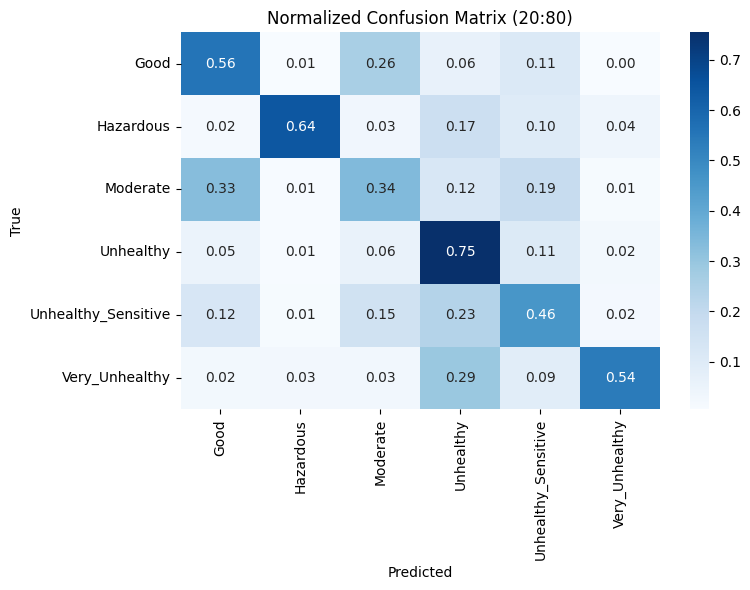

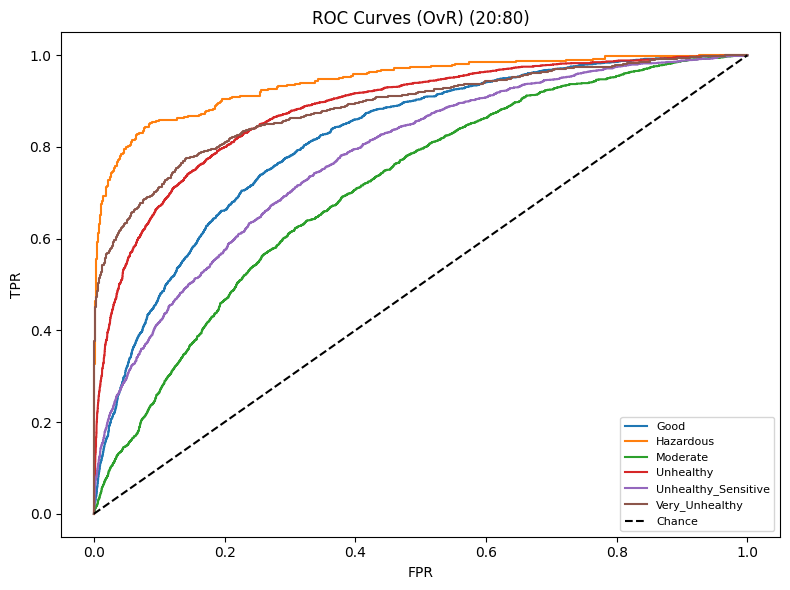


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.33
      Very_Unhealthy → Unhealthy          : 0.29
                Good → Moderate           : 0.26
  Unhealthy_Sensitive → Unhealthy          : 0.23
            Moderate → Unhealthy_Sensitive : 0.19

[TEST] Ratio 10:90


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 2.038, Test Accuracy: 0.475
Total Test Time: 74.97 seconds for 9993 images
Average Inference Time per Image: 0.007503 s (~7.50 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.451315
1            Hazardous  0.556582
2             Moderate  0.323950
3            Unhealthy  0.586334
4  Unhealthy_Sensitive  0.457289
5       Very_Unhealthy  0.624724

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4618    0.4513    0.4565      2167
          Hazardous     0.4725    0.5566    0.5111       433
           Moderate     0.3853    0.3240    0.3520      2167
          Unhealthy     0.5519    0.5863    0.5686      2166
Unhealthy_Sensitive     0.4682    0.4573    0.4627      2154
     Very_Unhealthy     0.4974    0.6247    0.5538       906

           accuracy                         0.4745      9993
          macro avg     0.4728    0.5000    0.4841      9993
       weighted avg     

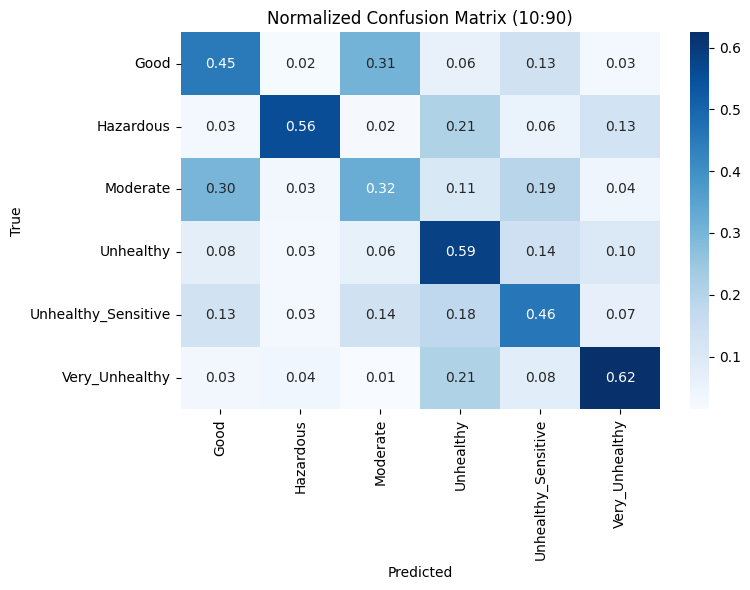

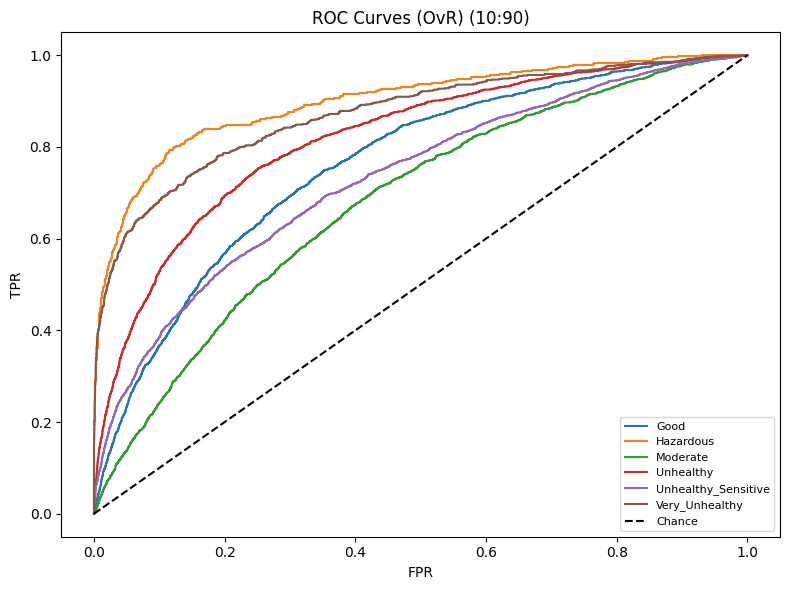


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.31
            Moderate → Good               : 0.30
      Very_Unhealthy → Unhealthy          : 0.21
           Hazardous → Unhealthy          : 0.21
            Moderate → Unhealthy_Sensitive : 0.19


In [22]:
import time
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns  

CLASS_NAMES = sorted(df['label'].unique())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}

for (tr, te) in RATIOS:
    print(f"\n[TEST] Ratio {tr}:{te}")
  
    save_path_checkpoints = os.path.join("/kaggle/working/task2_efficientnet_b0", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

   
    model = models.efficientnet_b0(pretrained=True).to(device)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, len(CLASS_NAMES))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_weight"])

    split = SPLITS[(tr, te)]
    _, _, dataloader_test_dataset = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    start_time = time.time()
    test_loss, test_accuracy, all_preds, all_labels, all_probs = evaluate_model(
        model, criterion, dataloader_test_dataset, return_preds=True
    )
    end_time = time.time()
    test_time = end_time - start_time

   
    n_test_images = len(split["test_df"])
    avg_inf_per_image_sec = test_time / n_test_images if n_test_images > 0 else float('nan')
    avg_inf_per_image_ms = avg_inf_per_image_sec * 1000.0

    print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_accuracy:.3f}")
    print(f"Total Test Time: {test_time:.2f} seconds for {n_test_images} images")
    print(f"Average Inference Time per Image: {avg_inf_per_image_sec:.6f} s (~{avg_inf_per_image_ms:.2f} ms/image)")

  
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_acc_df = pd.DataFrame({'Class': CLASS_NAMES, 'Accuracy': per_class_acc})
    print("\nPer-Class Accuracy:")
    print(per_class_acc_df)

    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
    print("\nClassification Report:\n")
    print(report)

  
    y_true_bin = None
    try:
        y_true_bin = label_binarize(all_labels, classes=np.arange(len(CLASS_NAMES)))
        macro_auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovr')
    except Exception:
        macro_auc = np.nan
    print(f"Macro ROC–AUC (OvR): {macro_auc if not np.isnan(macro_auc) else 'NA'}")


    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix ({tr}:{te})')
    cm_path = os.path.join(save_path_checkpoints, f'cm_norm_{tr}-{te}.png')
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()


    try:
        if y_true_bin is not None:
            plt.figure(figsize=(8, 6))
            for i, cname in enumerate(CLASS_NAMES):
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
                plt.plot(fpr, tpr, label=cname)
            plt.plot([0, 1], [0, 1], 'k--', label='Chance')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title(f'ROC Curves (OvR) ({tr}:{te})')
            plt.legend(fontsize=8)
            roc_path = os.path.join(save_path_checkpoints, f'roc_{tr}-{te}.png')
            plt.tight_layout()
            plt.savefig(roc_path)
            plt.show()
    except Exception:
        pass

    cm_norm_off = cm_norm.copy()
    np.fill_diagonal(cm_norm_off, 0.0)
  
    confused = []
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            if i == j:
                continue
            confused.append((CLASS_NAMES[i], CLASS_NAMES[j], cm_norm_off[i, j]))
    confused.sort(key=lambda x: x[2], reverse=True)
    top_k = [c for c in confused if np.isfinite(c[2]) and c[2] > 0][:5]
    if top_k:
        print("\nTop Confused Pairs (True → Pred, rate):")
        for (t, p, r) in top_k:
            print(f"  {t:>18s} → {p:<18s} : {r:.2f}")
    else:
        print("\nNo significant confused pairs detected.")
